In [2]:
!pip install tensorflow

In [3]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [6]:

# Update this path to your dataset location
file_path = '/content/Dataset.csv'  # Change this to your actual path
df = pd.read_csv(file_path)

# Display basic info
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nSentiment distribution:")
print(df['sentiment'].value_counts())

Dataset shape: (5000, 2)

First 5 rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive



Sentiment distribution:
sentiment
negative    2532
positive    2468
Name: count, dtype: int64


In [7]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Remove duplicates if any
df = df.drop_duplicates()
print("\nShape after removing duplicates:", df.shape)

# Verify sentiment labels
print("\nUnique sentiment values:", df['sentiment'].unique())

# If you need to convert sentiment to numerical values (for LSTM)
df['sentiment_num'] = df['sentiment'].map({'negative': 0, 'positive': 1})

Missing values:
 review       0
sentiment    0
dtype: int64

Shape after removing duplicates: (4997, 2)

Unique sentiment values: ['positive' 'negative']


In [8]:
# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert to lowercase
    text = text.lower()
    # Tokenize
    words = text.split()
    # Remove stopwords and lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    # Join back to string
    return ' '.join(words)

# Apply cleaning to reviews
df['cleaned_review'] = df['review'].apply(clean_text)

# Display before and after cleaning
print("Original review:\n", df['review'].iloc[0])
print("\nCleaned review:\n", df['cleaned_review'].iloc[0])

Original review:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show

In [9]:
df.head()

,review,sentiment,sentiment_num,cleaned_review
0,One of the other reviewers has mentioned that ...,positive,1,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,positive,1,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,1,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,0,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1,petter matteis love time money visually stunni...


In [10]:
# Split data into train and test sets (70/30)
X = df['cleaned_review']
y = df['sentiment_num']  # or use 'sentiment' for logistic regression if you prefer

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Training set size:", len(X_train))
print("Test set size:", len(X_test))
print("\nClass distribution in training set:\n", y_train.value_counts())
print("\nClass distribution in test set:\n", y_test.value_counts())

Training set size: 3497
Test set size: 1500

Class distribution in training set:
 sentiment_num
0    1771
1    1726
Name: count, dtype: int64

Class distribution in test set:
 sentiment_num
0    760
1    740
Name: count, dtype: int64


Logistic Regression Performance:
Accuracy: 0.862
Precision: 0.8596491228070176
Recall: 0.8608108108108108
F1 Score: 0.8602295746117489


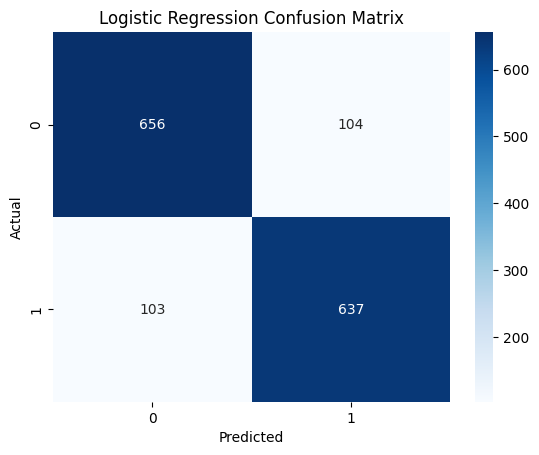


Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       760
           1       0.86      0.86      0.86       740

    accuracy                           0.86      1500
   macro avg       0.86      0.86      0.86      1500
weighted avg       0.86      0.86      0.86      1500



In [11]:
# TF-IDF Vectorization with N-Grams
tfidf = TfidfVectorizer(ngram_range=(1, 3), max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_tfidf)

# Evaluation
print("Logistic Regression Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

In [13]:
# Tokenization and Padding
max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

print("Training data shape:", X_train_pad.shape)
print("Test data shape:", X_test_pad.shape)

Training data shape: (3497, 200)
Test data shape: (1500, 200)


In [14]:
# Build LSTM Model
embedding_dim = 128

lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len),
    LSTM(128, return_sequences=True),
    Dropout(0.5),
    LSTM(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Explicitly build the model
lstm_model.build(input_shape=(None, max_len))

# Model Summary
lstm_model.summary()

# Compile the model
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 200, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,461,057 (5.57 MB)

 Trainable params: 1,461,057 (5.57 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Train LSTM Model
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=4,
    batch_size=64,
    callbacks=[early_stopping]
)

Epoch 1/4
55/55 ━━━━━━━━━━━━━━━━━━━━ 53s 969ms/step - accuracy: 0.9951 - loss: 0.0213 - val_accuracy: 0.7960 - val_loss: 0.7308
Epoch 2/4
55/55 ━━━━━━━━━━━━━━━━━━━━ 81s 950ms/step - accuracy: 0.9979 - loss: 0.0157 - val_accuracy: 0.7980 - val_loss: 0.9706
Epoch 3/4
55/55 ━━━━━━━━━━━━━━━━━━━━ 77s 856ms/step - accuracy: 0.9992 - loss: 0.0070 - val_accuracy: 0.8040 - val_loss: 1.0596
Epoch 4/4
55/55 ━━━━━━━━━━━━━━━━━━━━ 86s 945ms/step - accuracy: 0.9861 - loss: 0.0473 - val_accuracy: 0.7860 - val_loss: 0.8195


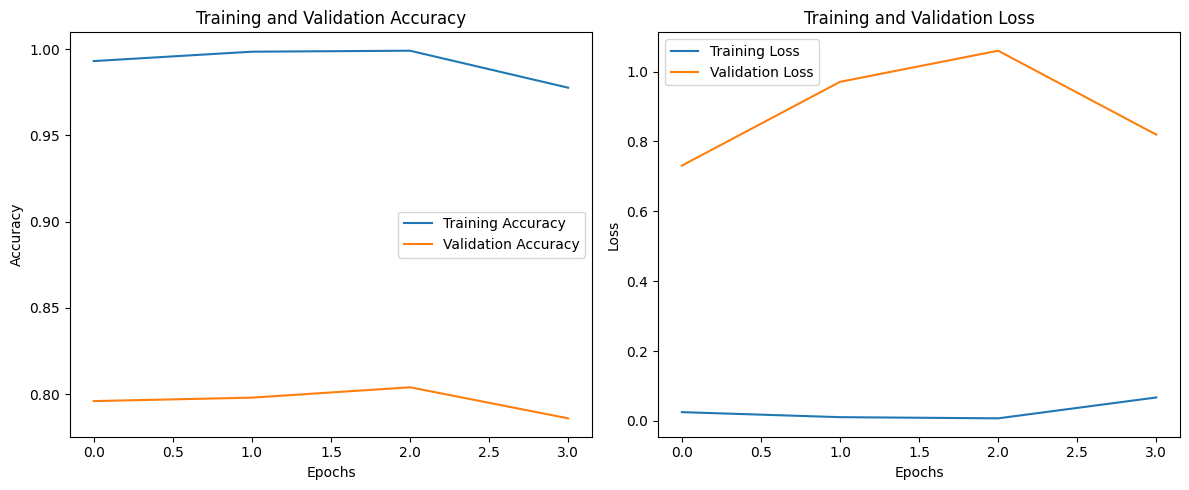

In [17]:
# Plot training history
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step
LSTM Performance:
--------------------------------------------------
Accuracy: 0.7960
Precision: 0.7878
Recall: 0.8027
F1 Score: 0.7952


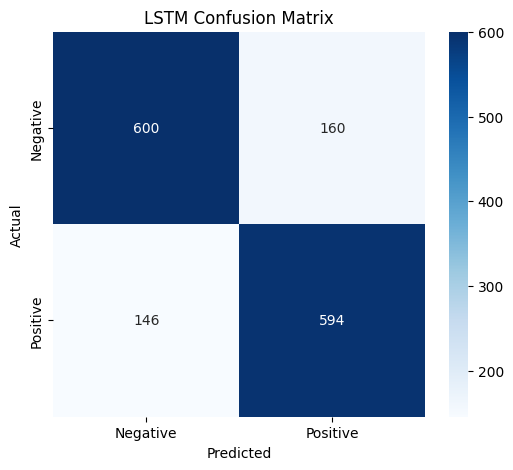


Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.80      0.79      0.80       760
    Positive       0.79      0.80      0.80       740

    accuracy                           0.80      1500
   macro avg       0.80      0.80      0.80      1500
weighted avg       0.80      0.80      0.80      1500



In [18]:
# Evaluate LSTM Model
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype("int32")

print("LSTM Performance:")
print("-" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lstm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lstm):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lstm):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_lstm):.4f}")

# Confusion Matrix
plt.figure(figsize=(6, 5))
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('LSTM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report:")
print("-" * 50)
print(classification_report(y_test, y_pred_lstm, target_names=['Negative', 'Positive']))

In [19]:
# Save models and vectorizers for the web app
import pickle
import joblib

# Save Logistic Regression model and TF-IDF vectorizer
joblib.dump(lr_model, 'logistic_regression_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

# Save LSTM model and tokenizer
lstm_model.save('lstm_model.h5')
with open('tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

Model Comparison:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.862,0.859649,0.860811,0.860230
1,LSTM,0.796,0.787798,0.802703,0.795181


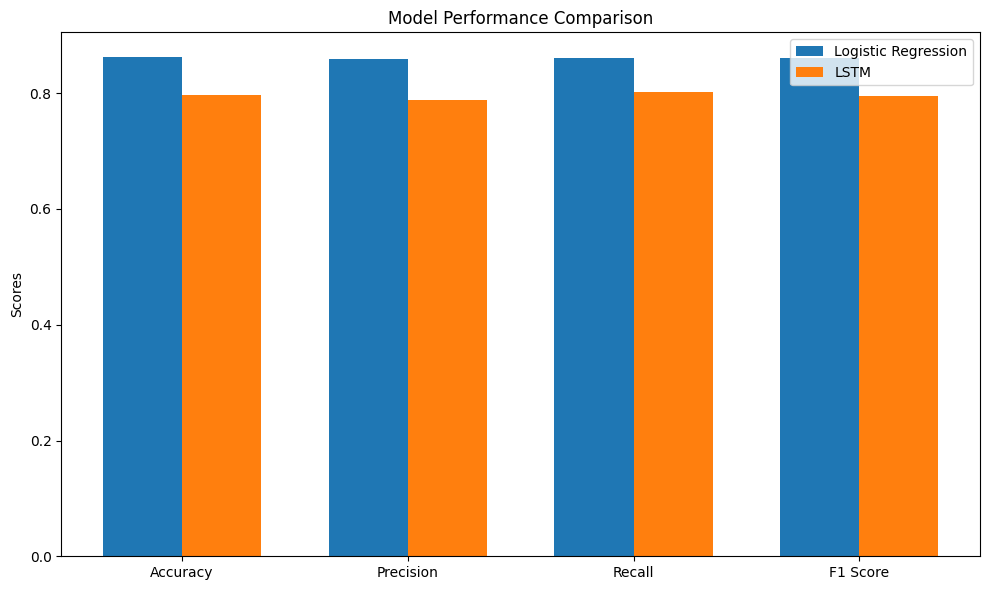

In [20]:
# Compare model performances
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'LSTM'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_lstm)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_lstm)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_lstm)],
    'F1 Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_lstm)]
})

print("Model Comparison:")
display(results)

# Plot comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, results.iloc[0, 1:], width, label='Logistic Regression')
rects2 = ax.bar(x + width/2, results.iloc[1, 1:], width, label='LSTM')

ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

fig.tight_layout()
plt.show()